# Data Quality Investigation

## Objective

During the initial EDA, unusually high values (such as 96 and 98) were observed in the delinquency-related features.

The objective of this section is to investigate whether these values represent genuine customer behaviour, data entry errors, or placeholder values before deciding how to handle them during preprocessing.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../Data/Raw/GiveMeSomeCredit-training.csv")

# Create a copy for analysis
credit_df = df.copy()

In [5]:
delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

In [6]:
credit_df[delinquency_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.0,0.0,0.0,98.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.0,0.0,0.0,98.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.0,0.0,0.0,98.0


In [7]:
for col in delinquency_cols:
    print(f"\n{col}")
    print("-"*50)

    print(
        credit_df[col]
        .value_counts()
        .sort_index()
        .tail(10)
    )


NumberOfTime30-59DaysPastDueNotWorse
--------------------------------------------------
NumberOfTime30-59DaysPastDueNotWorse
6     140
7      54
8      25
9      12
10      4
11      1
12      2
13      1
96      5
98    264
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
--------------------------------------------------
NumberOfTime60-89DaysPastDueNotWorse
3     318
4     105
5      34
6      16
7       9
8       2
9       1
11      1
96      5
98    264
Name: count, dtype: int64

NumberOfTimes90DaysLate
--------------------------------------------------
NumberOfTimes90DaysLate
9      19
10      8
11      5
12      2
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64


In [8]:
for col in delinquency_cols:
    print(f"{col}")

    print(
        (credit_df[col] >= 90).sum()
    )

    print()

NumberOfTime30-59DaysPastDueNotWorse
269

NumberOfTime60-89DaysPastDueNotWorse
269

NumberOfTimes90DaysLate
269



In [9]:
credit_df.loc[
    (credit_df["NumberOfTime30-59DaysPastDueNotWorse"] >= 90) |
    (credit_df["NumberOfTime60-89DaysPastDueNotWorse"] >= 90) |
    (credit_df["NumberOfTimes90DaysLate"] >= 90),
    delinquency_cols + ["SeriousDlqin2yrs"]
].head(20)

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,SeriousDlqin2yrs
1733,98,98,98,1
2286,98,98,98,0
3884,98,98,98,0
4417,98,98,98,0
4705,98,98,98,0
5073,98,98,98,0
6280,98,98,98,1
7032,98,98,98,1
7117,98,98,98,1
7687,98,98,98,1


In [12]:
anomaly_rows = credit_df[
    (credit_df["NumberOfTime30-59DaysPastDueNotWorse"] >= 90) |
    (credit_df["NumberOfTime60-89DaysPastDueNotWorse"] >= 90) |
    (credit_df["NumberOfTimes90DaysLate"] >= 90)
]

print(f"Total suspicious rows: {len(anomaly_rows)}")
print(f"Percentage of dataset: {(len(anomaly_rows)/len(credit_df))*100:.2f}%")
anomaly_rows["SeriousDlqin2yrs"].value_counts(normalize=True)*100

Total suspicious rows: 269
Percentage of dataset: 0.18%


SeriousDlqin2yrs
1    54.64684
0    45.35316
Name: proportion, dtype: float64

### Findings

- The values **96** and **98** appear consistently across all three delinquency-related features.
- These anomalous values occur in the **same 269 customer records (0.18% of the dataset)**.
- Such a pattern is highly unlikely to represent genuine counts of late payments and suggests that these values may be placeholder codes or data quality anomalies.
- Customers with these anomalous values exhibit a substantially higher observed default rate (approximately **54.6%**) compared to the overall dataset (**6.68%**).
- These observations will be considered during the preprocessing stage before model training.

# Data Quality Investigation: Age

## Objective

Age is an important demographic feature that may influence repayment behavior. Before analyzing its relationship with default risk, we first verify whether the recorded ages are realistic.

The objective is to identify impossible or highly unusual age values that may require treatment during preprocessing.

In [15]:
credit_df["age"].describe()

count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

In [18]:
credit_df["age"].value_counts().sort_index().head(10)

age
0        1
21     183
22     434
23     641
24     816
25     953
26    1193
27    1338
28    1560
29    1702
Name: count, dtype: int64

In [19]:
credit_df["age"].value_counts().sort_index().tail(10)

age
96     18
97     17
98      6
99      9
101     3
102     3
103     3
105     1
107     1
109     2
Name: count, dtype: int64

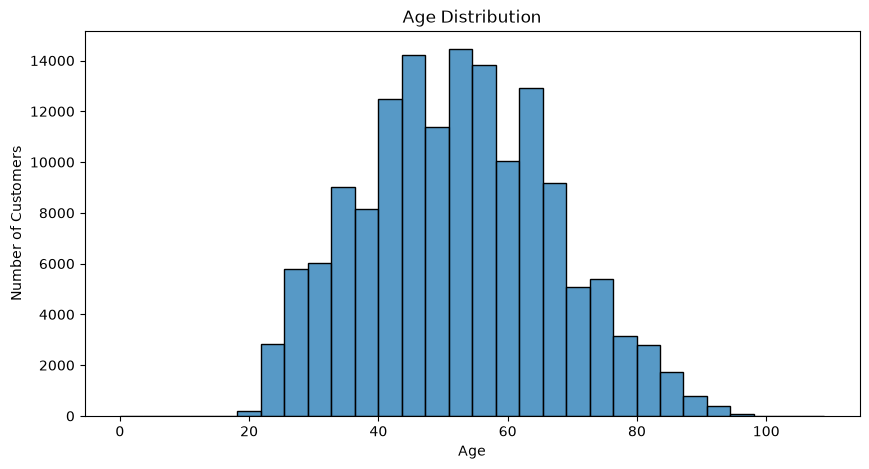

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    credit_df["age"],
    bins=30
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

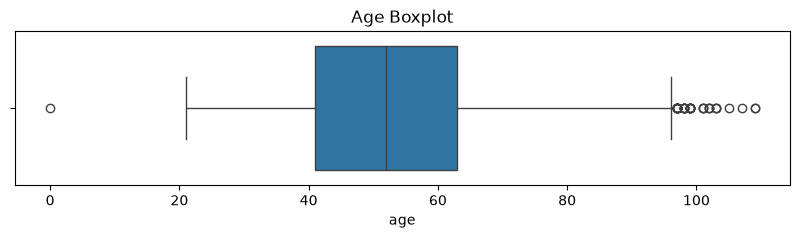

In [21]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=credit_df["age"]
)

plt.title("Age Boxplot")

plt.show()

In [22]:
credit_df[
    credit_df["age"] == 0
]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [24]:
age_default = (
    credit_df
    .groupby("age")["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

age_default.head(10)

,age,SeriousDlqin2yrs
0,0,0.000000
1,21,0.071038
2,22,0.082949
3,23,0.109204
4,24,0.120098
5,25,0.126967
6,26,0.123219
7,27,0.124066
8,28,0.131410
9,29,0.105170


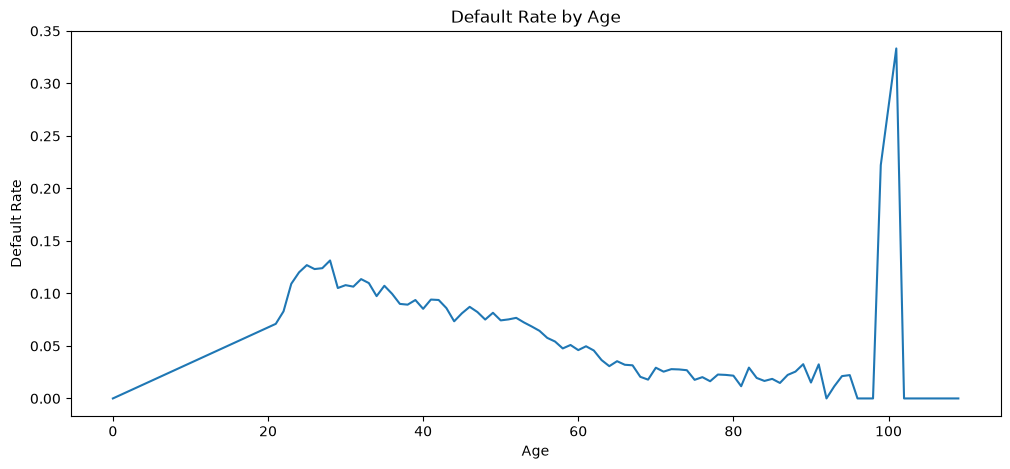

In [25]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=age_default,
    x="age",
    y="SeriousDlqin2yrs"
)

plt.ylabel("Default Rate")
plt.xlabel("Age")

plt.title("Default Rate by Age")

plt.show()

### Findings

- The minimum recorded age is **0**, which is not a valid age for a loan applicant and likely represents a data entry error.
- Only a single record contains this invalid value, making it a negligible portion of the dataset.
- The age distribution is slightly right-skewed, which is expected because fewer customers are in very old age groups.
- The maximum recorded age (109 years) is rare but plausible and will be retained unless further evidence suggests otherwise.

# Revolving Utilization of Unsecured Lines

## Objective

The **RevolvingUtilizationOfUnsecuredLines** feature represents the proportion of a customer's available unsecured revolving credit that is currently being utilized. Credit utilization is a widely used indicator of financial health and is expected to play a significant role in assessing credit risk.

The objective of this investigation is to examine the distribution of this feature, identify unusually large or unrealistic values, detect potential outliers or data quality issues, and determine whether any preprocessing is required before model development.

In [26]:
credit_df["RevolvingUtilizationOfUnsecuredLines"].describe()

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [30]:
credit_df["RevolvingUtilizationOfUnsecuredLines"].value_counts().sort_index().head(10)

RevolvingUtilizationOfUnsecuredLines
0.000000    10878
0.000008        1
0.000010        1
0.000013        1
0.000014        1
0.000015        1
0.000015        1
0.000016        1
0.000016        1
0.000019        1
Name: count, dtype: int64

In [31]:
credit_df["RevolvingUtilizationOfUnsecuredLines"].value_counts().sort_index().tail(10)

RevolvingUtilizationOfUnsecuredLines
13400.0    1
13498.0    1
13930.0    1
17441.0    1
18300.0    1
20514.0    1
22000.0    1
22198.0    1
29110.0    1
50708.0    1
Name: count, dtype: int64

In [37]:
credit_df[credit_df["RevolvingUtilizationOfUnsecuredLines"]>2].value_counts().sort_values().head(20)

Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio    MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents
294         0                 2340.000000                           45   0                                     0.339333     8333.0         7                                0                        2                             0                                     2.0                   1
698         1                 2066.000000                           58   0                                     0.271121     6000.0         8                                1                        1                             0                                     1.0                   1
901         0                 2.258964                              33   2                                     0.032484     2000.0        

In [39]:
credit_df["RevolvingUtilizationOfUnsecuredLines"].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995, 0.997, 0.999]
)

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
90%           0.981278
95%           1.000000
99%           1.092956
99.5%         1.366269
99.7%         1.760802
99.9%      1571.006000
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [47]:
print(f"RevolvingUtilizationOfUnsecuredLines beyond 1 values :",(credit_df["RevolvingUtilizationOfUnsecuredLines"] > 1).sum())
print(f"RevolvingUtilizationOfUnsecuredLines beyond 1 in percentage : ",(credit_df["RevolvingUtilizationOfUnsecuredLines"] > 1).mean() * 100)
print(f"RevolvingUtilizationOfUnsecuredLines beyond 5 values :",(credit_df["RevolvingUtilizationOfUnsecuredLines"] > 5).sum())
print(f"RevolvingUtilizationOfUnsecuredLines beyond 5 in percentage : ",(credit_df["RevolvingUtilizationOfUnsecuredLines"] > 5).mean() * 100)


RevolvingUtilizationOfUnsecuredLines beyond 1 values : 3321
RevolvingUtilizationOfUnsecuredLines beyond 1 in percentage :  2.214
RevolvingUtilizationOfUnsecuredLines beyond 5 values : 254
RevolvingUtilizationOfUnsecuredLines beyond 5 in percentage :  0.16933333333333334


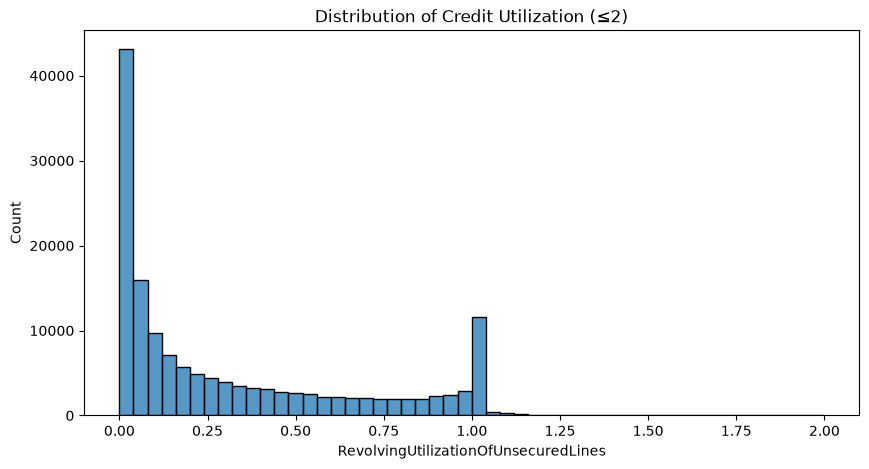

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(
    credit_df.loc[
        credit_df["RevolvingUtilizationOfUnsecuredLines"] <= 2,
        "RevolvingUtilizationOfUnsecuredLines"
    ],
    bins=50
)

plt.title("Distribution of Credit Utilization (≤2)")
plt.show()

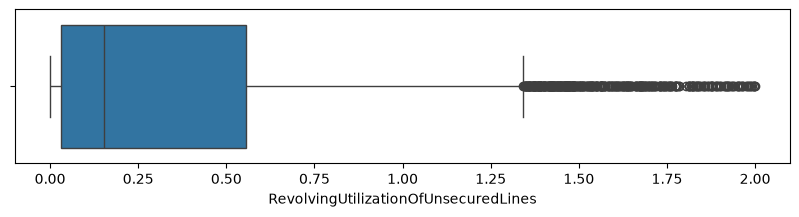

In [50]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=credit_df.loc[
        credit_df["RevolvingUtilizationOfUnsecuredLines"] <= 2,
        "RevolvingUtilizationOfUnsecuredLines"
    ]
)

plt.show()

### Findings

- The distribution of **RevolvingUtilizationOfUnsecuredLines** is highly right-skewed.
- Approximately **99%** of customers have a utilization value below **1.10**, indicating that most observations fall within a realistic range.
- Around **2.21%** of customers have utilization values greater than **1**, which may occur due to over-limit balances, accrued interest, or reporting differences.
- Only **0.17%** of customers have utilization values greater than **5**, suggesting the presence of a very small number of extreme observations.
- The feature exhibits a sharp increase in values beyond the **99.7th percentile**, with the maximum reaching **50,708**. These extreme values substantially inflate the mean and are likely anomalous.
- These observations indicate that this feature contains significant outliers and should be carefully handled during the preprocessing stage.

#  Debt Ratio

## Objective

The **DebtRatio** feature represents the ratio of a customer's monthly debt obligations to their monthly income. It is an important financial indicator used to assess an individual's repayment capacity.

The objective of this investigation is to examine the distribution of debt ratios, identify unusually large or unrealistic values, detect potential outliers, and determine whether any preprocessing is required before model development.

In [67]:
credit_df["DebtRatio"].describe(
    percentiles=[0.75, 0.78, 0.79, 0.8, 0.85, 0.90,0.95,0.99,0.995,0.999]
)

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
75%           0.868254
78%           1.275069
79%           1.759204
80%           4.000000
85%         269.150000
90%        1267.000000
95%        2449.000000
99%        4979.040000
99.5%      6186.010000
99.9%     10613.074000
max      329664.000000
Name: DebtRatio, dtype: float64

In [60]:
credit_df["DebtRatio"].sort_values().head(20)

53290     0.0
8840      0.0
43172     0.0
65975     0.0
53149     0.0
53169     0.0
53345     0.0
145526    0.0
105571    0.0
86563     0.0
11743     0.0
127554    0.0
52        0.0
43164     0.0
149998    0.0
53275     0.0
53296     0.0
101606    0.0
138952    0.0
19261     0.0
Name: DebtRatio, dtype: float64

In [61]:
credit_df["DebtRatio"].sort_values().tail(20)

119909     34102.0
123260     34719.0
144341     36705.0
46404      38793.0
106447     40362.0
27188      40385.0
36666      43843.0
146310     49112.0
46102      52112.0
127898     60212.0
53682      61106.5
66785      61907.0
69845     101320.0
103041    106885.0
7513      110952.0
4854      168835.0
58900     220516.0
127047    307001.0
36600     326442.0
60152     329664.0
Name: DebtRatio, dtype: float64

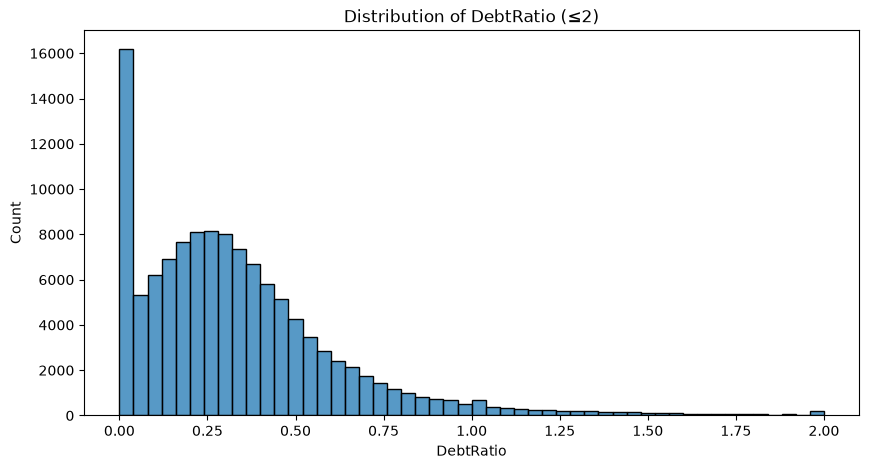

In [70]:
plt.figure(figsize=(10,5))

sns.histplot(
    credit_df.loc[
        credit_df["DebtRatio"] <= 2,
        "DebtRatio"
    ],
    bins=50
)

plt.title("Distribution of DebtRatio (≤2)")
plt.show()

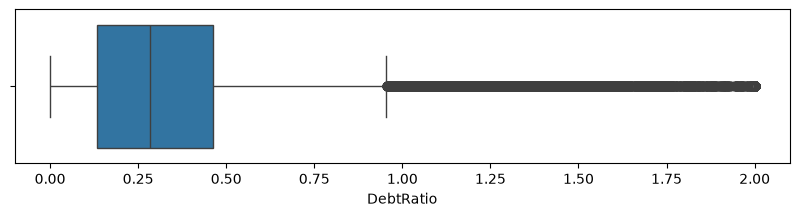

In [71]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=credit_df.loc[
        credit_df["DebtRatio"] <= 2,
        "DebtRatio"
    ]
)

plt.show()

In [72]:
thresholds = [1, 2, 5, 10, 100, 1000]

for t in thresholds:
    count = (credit_df["DebtRatio"] > t).sum()
    pct = count / len(credit_df) * 100
    print(f"> {t:<4}: {count:>6} ({pct:.2f}%)")

> 1   :  35137 (23.42%)
> 2   :  31045 (20.70%)
> 5   :  29646 (19.76%)
> 10  :  28877 (19.25%)
> 100 :  24380 (16.25%)
> 1000:  16892 (11.26%)


In [73]:
high_debt = credit_df[credit_df["DebtRatio"] > 100]

high_debt[["DebtRatio", "MonthlyIncome"]].head(20)

,DebtRatio,MonthlyIncome
6,5710.0,NaN
14,477.0,0.0
16,2058.0,NaN
32,977.0,NaN
44,1687.5,1.0
50,3095.0,0.0
58,2477.0,NaN
62,1720.0,NaN
71,1824.0,NaN
73,3162.0,0.0


In [74]:
high_debt["MonthlyIncome"].isnull().sum()

np.int64(22693)

In [75]:
(high_debt["MonthlyIncome"] == 0).sum()

np.int64(1219)

In [ ]:
high_debt = credit_df[credit_df["DebtRatio"] > 100]
(high_debt["MonthlyIncome"].isna().sum()+ (high_debt["MonthlyIncome"] == 0).sum()) / len(high_debt) * 100

np.float64(98.08039376538146)

### Findings

- The **DebtRatio** feature exhibits a highly right-skewed distribution.
- The majority of customers have debt ratios below **1**, while a small subset contains extremely large values.
- The maximum recorded debt ratio is **329,664**, which is substantially higher than typical values and strongly influences the mean.
- A large proportion of customers with **DebtRatio > 100** have either missing or zero monthly income, suggesting that these unusually high ratios may be associated with unavailable or extremely low income values rather than exceptionally high debt obligations.
- These observations indicate that the feature requires careful preprocessing before model development.

Monthly Income

## Objective

The **MonthlyIncome** feature represents the customer's reported monthly earnings and is an important indicator of repayment capacity.

The objective of this investigation is to examine the distribution of income values, identify missing or unrealistic values, detect potential outliers, and assess whether preprocessing is required before model development.

In [ ]:
credit_df["MonthlyIncome"].isnull().sum()

np.float64(19.820666666666668)

In [79]:
credit_df["MonthlyIncome"].isnull().mean() * 100

np.float64(19.820666666666668)

In [80]:
credit_df["MonthlyIncome"].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
)

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
90%      1.166600e+04
95%      1.458760e+04
99%      2.500000e+04
99.5%    3.500000e+04
99.9%    7.839575e+04
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [81]:
(credit_df["MonthlyIncome"] == 0).sum()

np.int64(1634)

In [82]:
credit_df.loc[
    credit_df["MonthlyIncome"] <= 30000,
    "MonthlyIncome"
]

0         9120.0
1         2600.0
2         3042.0
3         3300.0
5         3500.0
           ...  
149994    3400.0
149995    2100.0
149996    5584.0
149998    5716.0
149999    8158.0
Name: MonthlyIncome, Length: 119477, dtype: float64

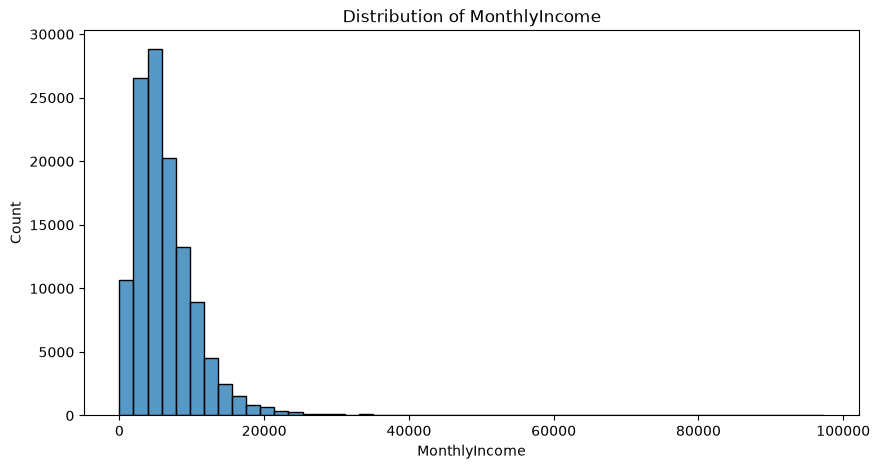

In [85]:
plt.figure(figsize=(10,5))

sns.histplot(
    credit_df.loc[
        credit_df["MonthlyIncome"] < 100000,
        "MonthlyIncome"
    ],
    bins=50
)

plt.title("Distribution of MonthlyIncome")
plt.show()

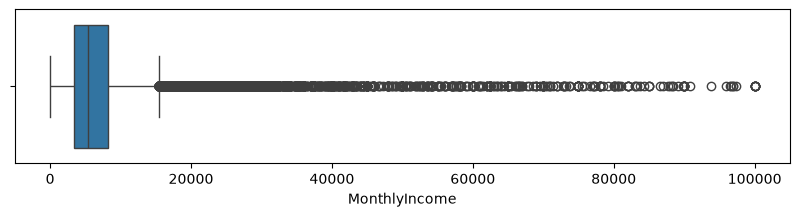

In [88]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=credit_df.loc[
        credit_df["MonthlyIncome"] <= 100000,
        "MonthlyIncome"
    ]
)

plt.show()

In [89]:
credit_df["MonthlyIncome"].sort_values().tail(20)

149924   NaN
149931   NaN
149932   NaN
149935   NaN
149940   NaN
149946   NaN
149948   NaN
149952   NaN
149953   NaN
149958   NaN
149960   NaN
149963   NaN
149965   NaN
149967   NaN
149975   NaN
149976   NaN
149977   NaN
149984   NaN
149992   NaN
149997   NaN
Name: MonthlyIncome, dtype: float64

In [90]:
credit_df["MonthlyIncome"].sort_values().tail(20).values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan])

### Findings

- The **MonthlyIncome** feature contains approximately **19.82% missing values**, making it the feature with the highest proportion of missing data in the dataset.
- Around **1.09%** of customers report a monthly income of zero. While uncommon, these values are not necessarily invalid and may represent unemployed or non-earning individuals.
- The distribution of monthly income is highly right-skewed, with most customers earning substantially less than the maximum reported income.
- A very small number of observations contain exceptionally large income values, which are likely to influence summary statistics such as the mean.
- The feature will require missing value treatment and careful handling of extreme outliers during preprocessing.

# Number of Dependents

## Objective

The **NumberOfDependents** feature represents the number of individuals who financially depend on the customer. It provides insight into the customer's financial responsibilities and may influence repayment capacity.

The objective of this investigation is to examine the distribution of dependent counts, identify missing or unusual values, detect potential outliers, and determine whether any preprocessing is required before model development.

In [ ]:
missing_count = credit_df["NumberOfDependents"].isnull().sum()
missing_percentage = credit_df["NumberOfDependents"].isnull().mean() * 100

print(f"Missing Values : {missing_count}")
print(f"Missing Percentage : {missing_percentage:.2f}%")

Missing Values : 3924
Missing Percentage : 2.62%


In [92]:
credit_df["NumberOfDependents"].describe(
    percentiles=[0.90, 0.95, 0.99]
)

count    146076.000000
mean          0.757222
std           1.115086
min           0.000000
90%           2.000000
95%           3.000000
99%           4.000000
max          20.000000
Name: NumberOfDependents, dtype: float64

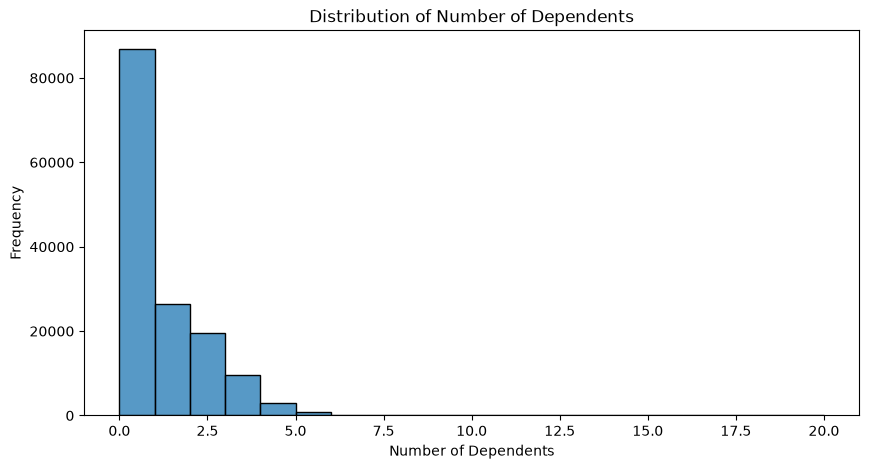

In [93]:
plt.figure(figsize=(10,5))

sns.histplot(
    credit_df["NumberOfDependents"],
    bins=20
)

plt.title("Distribution of Number of Dependents")
plt.xlabel("Number of Dependents")
plt.ylabel("Frequency")

plt.show()

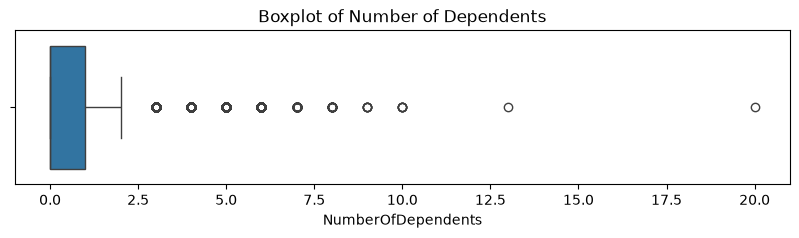

In [94]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=credit_df["NumberOfDependents"]
)

plt.title("Boxplot of Number of Dependents")

plt.show()

In [95]:
credit_df["NumberOfDependents"].value_counts().sort_index()

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
9.0         5
10.0        5
13.0        1
20.0        1
Name: count, dtype: int64

In [97]:
credit_df["NumberOfDependents"].sort_values().tail()

149826   NaN
149854   NaN
149894   NaN
149948   NaN
149965   NaN
Name: NumberOfDependents, dtype: float64

### Findings

- The **NumberOfDependents** feature contains a small proportion of missing values.
- Most customers have **0 to 2 dependents**, indicating a positively skewed distribution.
- A few observations contain unusually high numbers of dependents and will be reviewed during preprocessing.
- The feature appears largely consistent, with missing values being the primary data quality concern.

# Overall Data Quality Summary

| Feature | Issue Identified | Observation |
|---------|------------------|-------------|
| Age | Invalid value | One customer has age = 0 |
| Delinquency Features | Anomalous values | Values 96 and 98 appear consistently across all delinquency features |
| RevolvingUtilizationOfUnsecuredLines | Extreme outliers | Majority of values are below 1.1, while a very small number of observations contain exceptionally high values |
| DebtRatio | Highly skewed distribution | Extreme values are associated with many missing or zero monthly income records |
| MonthlyIncome | Missing values | Approximately 19.82% of observations have missing monthly income |
| NumberOfDependents | Missing values | Approximately 2.62% of observations have missing values |
| Duplicate Records | Pending | No duplicate rows detected (or update after investigation) |

The dataset is generally suitable for analysis; however, several data quality issues have been identified. These issues will be systematically addressed during the preprocessing stage before model training.